# Netflix Content Analysis — Python Version
**Dataset:** Kaggle Netflix Titles dataset
**Goal:** Replicate the Excel dashboard (Content by Type, Rating, Country, Genre, Year Added) using pandas + matplotlib/seaborn, and add a few extra insights.

This notebook is built to run in **Google Colab**. Upload `netflix_titles.csv` (the raw Kaggle file) when prompted, or mount Google Drive.

In [1]:
# If running in Colab, upload the raw Kaggle CSV (netflix_titles.csv)
try:
    from google.colab import files
    uploaded = files.upload()
    csv_path = list(uploaded.keys())[0]
except ImportError:
    # Running locally
    csv_path = 'netflix_titles.csv'


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv(csv_path)
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 1. Cleaning — same transformations as the Excel Raw Data sheet

In [3]:
# Fill missing values (mirrors 'Unknown' convention used in the Excel version)
for col in ['director', 'cast', 'country']:
    df[col] = df[col].fillna('Unknown')

# Parse date_added -> year_added, month_added
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# Split duration into value + unit
dur_split = df['duration'].str.extract(r'(?P<duration_value>\d+)\s*(?P<duration_unit>[a-zA-Z()]+)')
df['duration_value'] = pd.to_numeric(dur_split['duration_value'])
df['duration_unit'] = dur_split['duration_unit'].replace({'Season': 'Season(s)', 'Seasons': 'Season(s)'})

# Primary country = first country listed
df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0].strip())

# Primary genre = first genre listed
df['primary_genre'] = df['listed_in'].apply(lambda x: str(x).split(',')[0].strip())

df[['title', 'year_added', 'month_added', 'duration_value', 'duration_unit', 'primary_country', 'primary_genre']].head()


,title,year_added,month_added,duration_value,duration_unit,primary_country,primary_genre
0,Dick Johnson Is Dead,2021,September,90.0,min,United States,Documentaries
1,Blood & Water,2021,September,2.0,Season(s),South Africa,International TV Shows
2,Ganglands,2021,September,1.0,Season(s),Unknown,Crime TV Shows
3,Jailbirds New Orleans,2021,September,1.0,Season(s),Unknown,Docuseries
4,Kota Factory,2021,September,2.0,Season(s),India,International TV Shows


## 2. KPI cards (Dashboard top row)

In [4]:
total_titles = len(df)
movies = (df['type'] == 'Movie').sum()
tv_shows = (df['type'] == 'TV Show').sum()
countries = df['primary_country'].nunique()

print(f"Total Titles: {total_titles}")
print(f"Movies: {movies}")
print(f"TV Shows: {tv_shows}")
print(f"Countries Represented: {countries}")


Total Titles: 8793
Movies: 6129
TV Shows: 2664
Countries Represented: 87


## 3. Content by Type

type
Movie      6129
TV Show    2664
Name: count, dtype: int64
type
Movie      69.7
TV Show    30.3
Name: count, dtype: float64


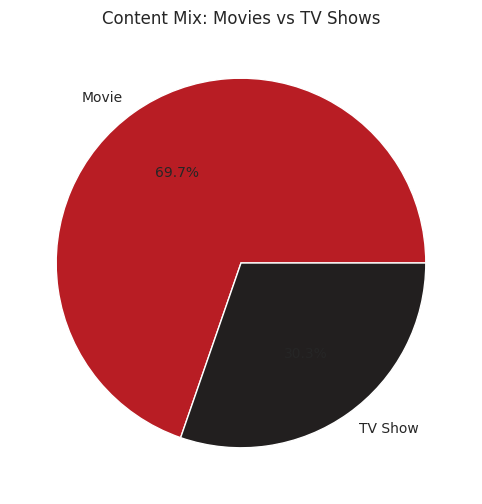

In [5]:
type_counts = df['type'].value_counts()
type_pct = (type_counts / total_titles * 100).round(1)
print(type_counts)
print(type_pct)

plt.figure()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
        colors=['#B81D24', '#221F1F'])
plt.title('Content Mix: Movies vs TV Shows')
plt.show()


## 4. Content by Rating (Top 10)

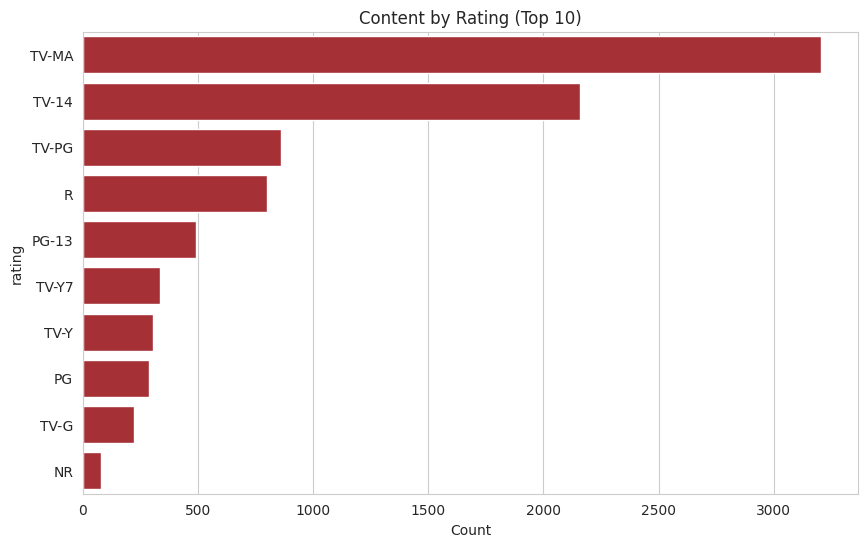

In [6]:
rating_counts = df['rating'].value_counts().head(10)

plt.figure()
sns.barplot(x=rating_counts.values, y=rating_counts.index, color='#B81D24')
plt.title('Content by Rating (Top 10)')
plt.xlabel('Count')
plt.show()


## 5. Top 10 Countries by Content Count

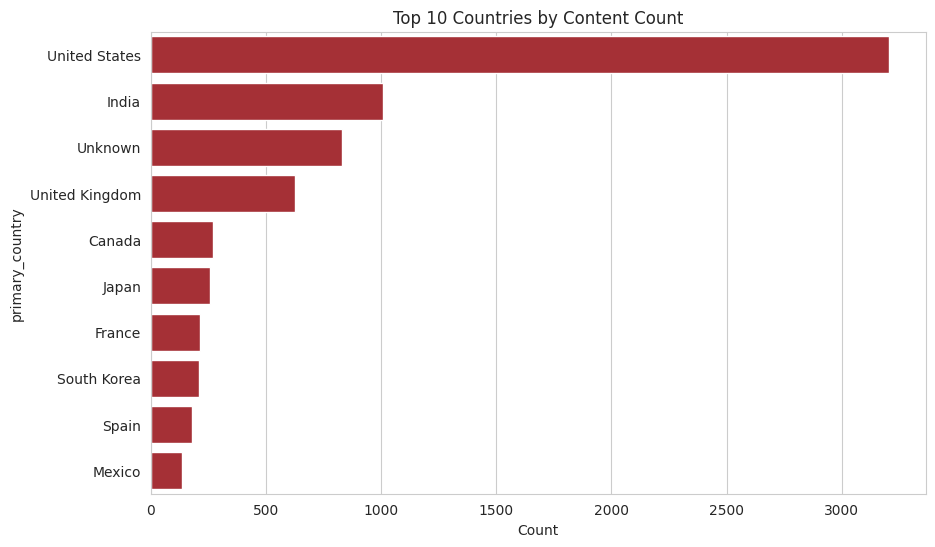

In [7]:
country_counts = df['primary_country'].value_counts().head(10)

plt.figure()
sns.barplot(x=country_counts.values, y=country_counts.index, color='#B81D24')
plt.title('Top 10 Countries by Content Count')
plt.xlabel('Count')
plt.show()


## 6. Top 10 Genres

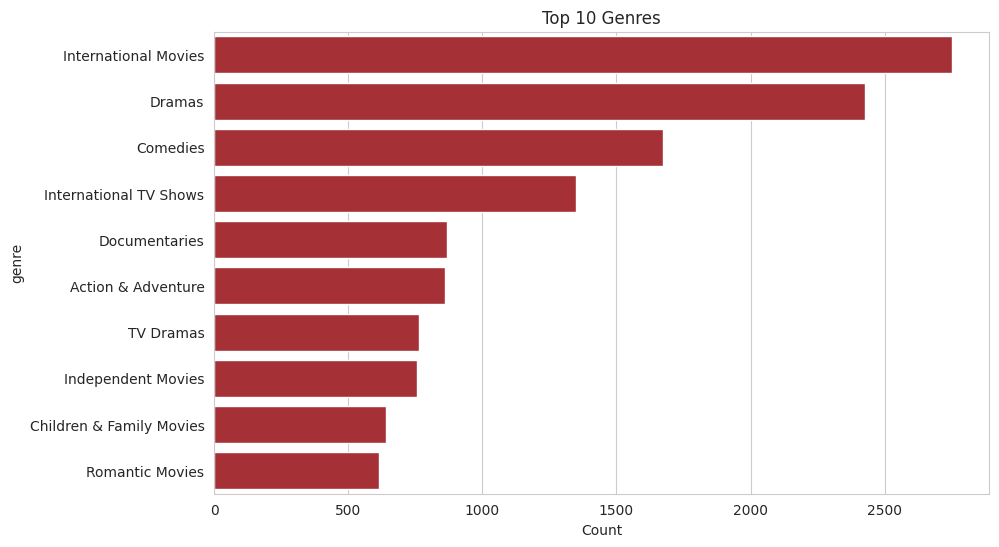

In [8]:
# Explode listed_in into one row per genre (mirrors the 'Genre Data' sheet)
genre_df = df[['show_id', 'listed_in']].copy()
genre_df['genre'] = genre_df['listed_in'].str.split(',')
genre_df = genre_df.explode('genre')
genre_df['genre'] = genre_df['genre'].str.strip()

genre_counts = genre_df['genre'].value_counts().head(10)

plt.figure()
sns.barplot(x=genre_counts.values, y=genre_counts.index, color='#B81D24')
plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.show()


## 7. Titles Added by Year

type        Movie  TV Show  Total
year_added                       
2008            1        1      2
2009            2        0      2
2010            1        0      1
2011           13        0     13
2012            3        0      3
2013            6        5     11
2014           19        5     24
2015           56       26     82
2016          253      175    428
2017          837      349   1186
2018         1237      411   1648
2019         1424      592   2016
2020         1284      595   1879
2021          993      505   1498


<Figure size 1000x600 with 0 Axes>

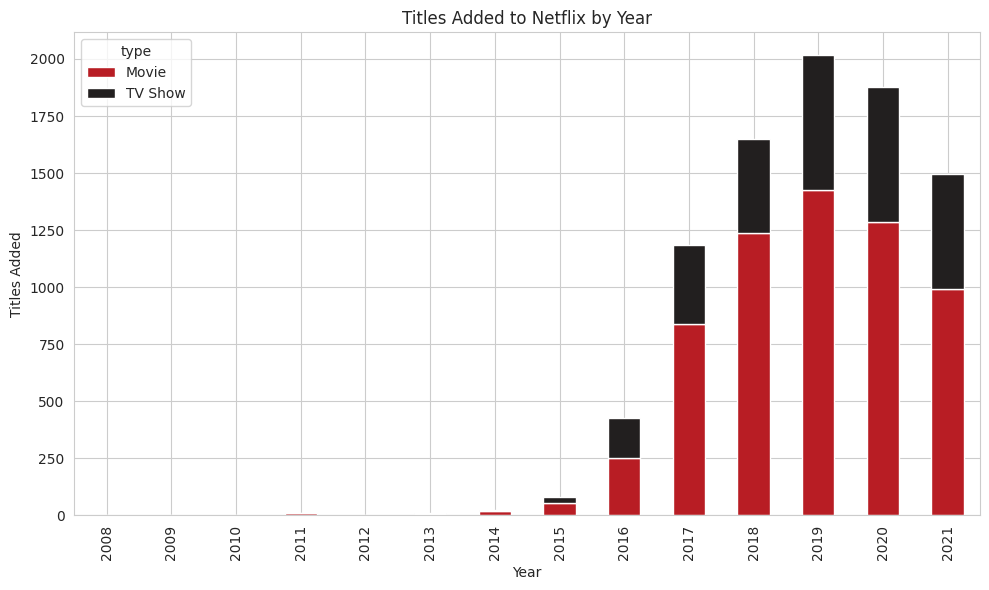

In [9]:
year_type = df.dropna(subset=['year_added']).groupby(['year_added', 'type']).size().unstack(fill_value=0)
year_type['Total'] = year_type.sum(axis=1)
print(year_type)

plt.figure()
year_type[['Movie', 'TV Show']].plot(kind='bar', stacked=True, color=['#B81D24', '#221F1F'])
plt.title('Titles Added to Netflix by Year')
plt.xlabel('Year')
plt.ylabel('Titles Added')
plt.tight_layout()
plt.show()


## 8. Bonus insights (not in the Excel version)
Good extra talking points for a portfolio / interview.

In [10]:
# 8a. Average movie duration by decade of release
movies_df = df[(df['type'] == 'Movie') & (df['duration_unit'] == 'min')].copy()
movies_df['decade'] = (movies_df['release_year'] // 10) * 10
avg_duration = movies_df.groupby('decade')['duration_value'].mean().round(1)
print(avg_duration)


decade
1940     51.4
1950    107.1
1960    147.6
1970    119.2
1980    116.2
1990    113.8
2000    112.1
2010     96.9
2020     93.6
Name: duration_value, dtype: float64


In [11]:
# 8b. Top 10 directors by title count (excluding Unknown)
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)
print(top_directors)


director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


In [12]:
# 8c. Month-of-year seasonality
month_counts = df['month_added'].value_counts()
print(month_counts)


month_added
July         827
December     812
September    770
April        764
October      760
August       755
March        741
January      737
June         728
November     705
May          632
February     562
Name: count, dtype: int64


In [13]:
# 8d. India-specific genre mix
india_genres = genre_df.merge(df[['show_id', 'primary_country']], on='show_id')
india_genres = india_genres[india_genres['primary_country'] == 'India']
print(india_genres['genre'].value_counts().head(10))


genre
International Movies      845
Dramas                    645
Comedies                  315
Independent Movies        162
Action & Adventure        130
Romantic Movies           120
Music & Musicals           93
Thrillers                  91
International TV Shows     66
Horror Movies              34
Name: count, dtype: int64


## 9. Key Findings

- Movies dominate the catalog at ~70% vs TV Shows at ~30%.
- Mature-audience ratings (TV-MA, TV-14) make up over 60% of all titles.
- The U.S. leads content volume, but India ranks #2 — ahead of the UK — showing Netflix's strong investment in Indian content.
- International Movies and Dramas are the top two genres.
- Content additions peaked in 2019, then declined — likely tied to pandemic-era production slowdowns.